In [88]:
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [89]:
data=pd.read_csv("bank.csv",sep=';')

### Categorical variable

In [91]:
from sklearn.model_selection import train_test_split

In [92]:
train,test=train_test_split(data,test_size=0.25)

In [93]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30891 entries, 18272 to 20244
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             30891 non-null  int64  
 1   job             30891 non-null  object 
 2   marital         30891 non-null  object 
 3   education       30891 non-null  object 
 4   default         30891 non-null  object 
 5   housing         30891 non-null  object 
 6   loan            30891 non-null  object 
 7   contact         30891 non-null  object 
 8   month           30891 non-null  object 
 9   day_of_week     30891 non-null  object 
 10  duration        30891 non-null  int64  
 11  campaign        30891 non-null  int64  
 12  pdays           30891 non-null  int64  
 13  previous        30891 non-null  int64  
 14  poutcome        30891 non-null  object 
 15  emp.var.rate    30891 non-null  float64
 16  cons.price.idx  30891 non-null  float64
 17  cons.conf.idx   30891 non-null  

In [94]:
train['y']=train.y.map({'yes':1,"no":0})

In [95]:
test['y']=test.y.map({'yes':1,'no':0})

In [96]:
train.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [97]:
train.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,30891.000000,30891.000000,30891.000000,30891.000000,30891.000000,30891.000000,30891.000000,30891.000000,30891.000000,30891.000000,30891.000000
mean,40.057816,257.425464,2.578291,962.739406,0.172736,0.070231,93.570508,-40.493752,3.610144,5166.577793,0.113237
std,10.446848,259.506954,2.780333,186.264009,0.494982,1.575478,0.578326,4.648075,1.738038,72.415038,0.316887
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.000000,179.000000,2.000000,999.000000,0.000000,1.100000,93.444000,-41.800000,4.857000,5191.000000,0.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


 `age binning`

/var/folders/pb/lrccxhdn21v014jb8bt4rb_r0000gn/T/ipykernel_11734/1342251261.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train.age)


<Axes: xlabel='age', ylabel='Density'>

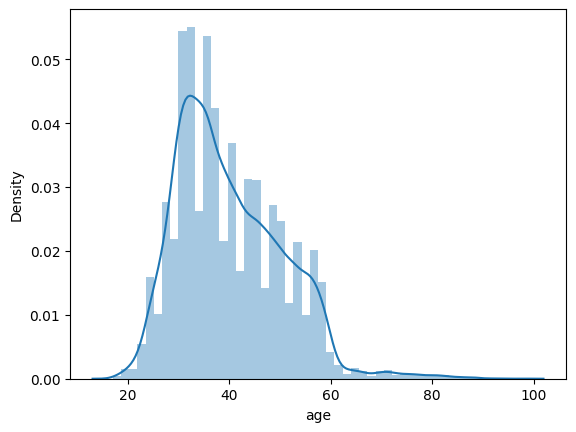

In [99]:
sns.distplot(train.age)

In [100]:
# bins [0-25,25-50,50-75,75-100]
bins=[0,25,50,75,100]
labels=['0-25','25-50','50-75','75-100']
train['age_bins']=pd.cut(train.age, bins=bins, labels=labels)

/var/folders/pb/lrccxhdn21v014jb8bt4rb_r0000gn/T/ipykernel_11734/354936467.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train.groupby('age_bins')['y'].mean().plot.barh()


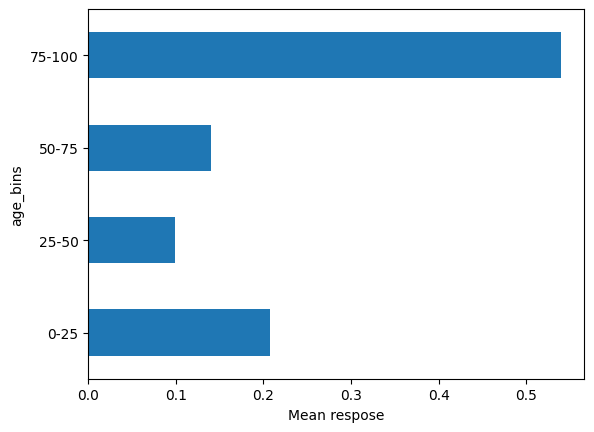

In [101]:
train.groupby('age_bins')['y'].mean().plot.barh()
plt.xlabel("Mean respose");
plt.show()

In [102]:
bins=[0,0.25,0.5,0.75,1]
label=['VL','low','medium','high', 'VH']
train['age_bins']= pd.qcut(train.age,bins,labels)

In [103]:
train.groupby('age_bins')['age'].agg(['min','max'])

/var/folders/pb/lrccxhdn21v014jb8bt4rb_r0000gn/T/ipykernel_11734/2135535069.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train.groupby('age_bins')['age'].agg(['min','max'])


,min,max
age_bins,,
0-25,17,32
25-50,33,38
50-75,39,47
75-100,48,98


<Axes: ylabel='Frequency'>

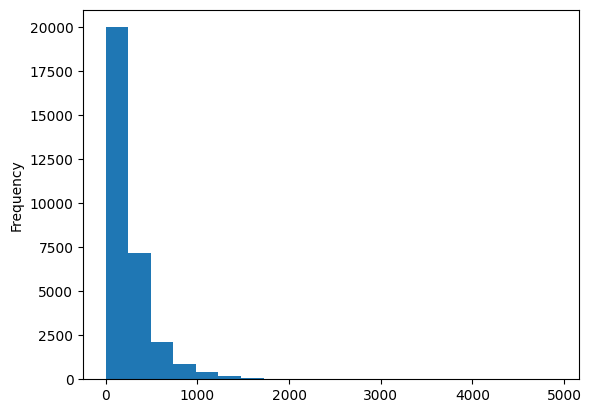

In [104]:
train.duration.plot.hist(bins=20)

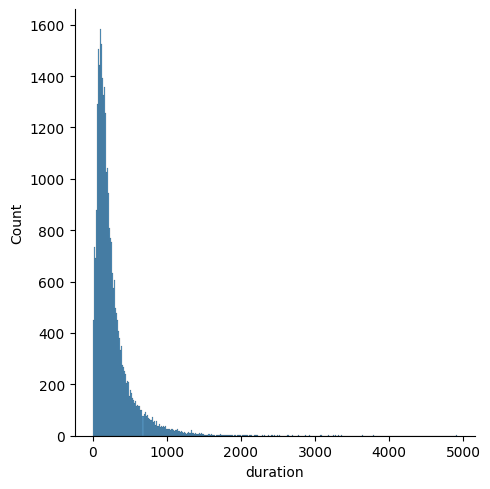

In [105]:
sns.displot(train.duration)

# Ckewed data can be normalized with 3 methods
- Log tranformation
- poer transformation
- BoxCox transformation
- yeo-johnson method

In [107]:
train['duration_log']=np.log1p(train.duration)

<Axes: ylabel='duration_log'>

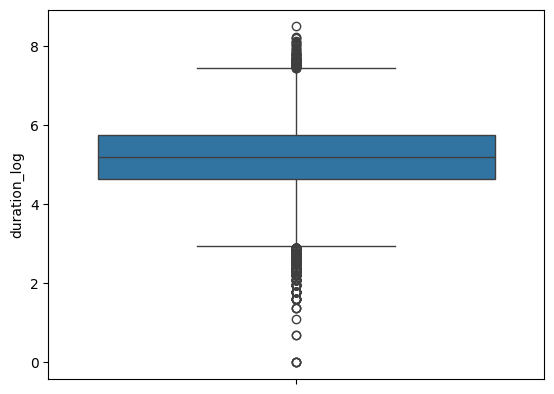

In [108]:
sns.boxplot(train.duration_log)

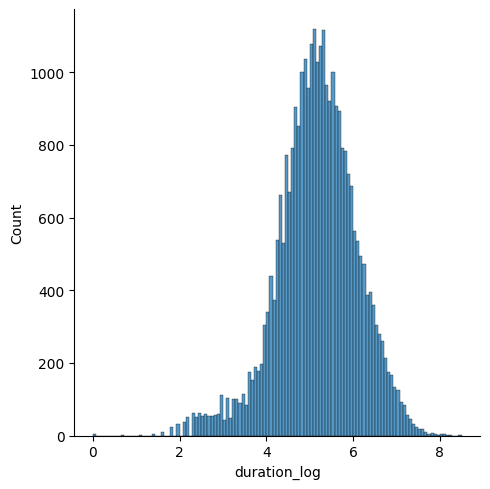

In [127]:
sns.displot(train.duration_log)

In [129]:
# Power transformation
from sklearn.preprocessing import PowerTransformer

In [135]:
train['duration_pt']=PowerTransformer().fit_transform(train.duration.values.reshape(-1,1))

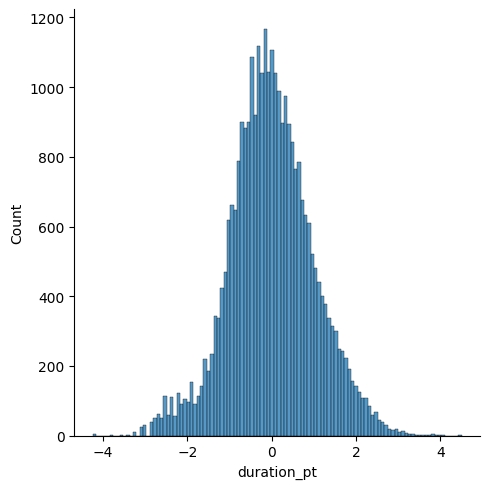

In [137]:
sns.displot(train.duration_pt)

In [141]:
# Box-cox transformation
from scipy.stats import boxcox

In [143]:
boxcox(train.duration)
# Error due to -ve values

ValueError: Data must be positive.

In [149]:
# yeo-johnsom method
train['dur_yeo_johnson']=PowerTransformer(method='yeo-johnson').fit_transform(train.duration.values.reshape(-1,1))

/var/folders/pb/lrccxhdn21v014jb8bt4rb_r0000gn/T/ipykernel_11734/2076241628.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train.dur_yeo_johnson)


<Axes: xlabel='dur_yeo_johnson', ylabel='Density'>

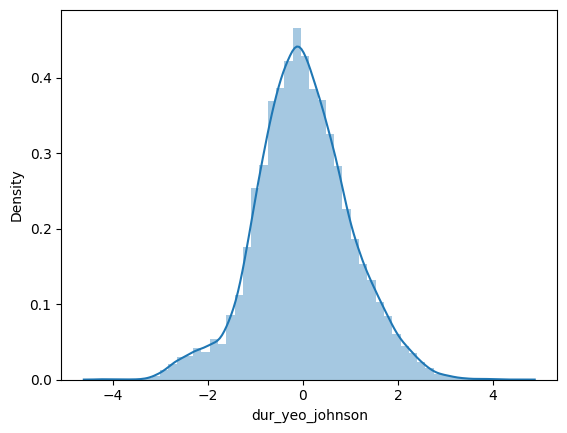

In [151]:
sns.distplot(train.dur_yeo_johnson)

In [157]:
pd.get_dummies(train, columns=['marital','job'], drop_first=True)

,age,education,default,housing,loan,contact,month,day_of_week,duration,campaign,...,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown
18272,35,professional.course,no,yes,yes,cellular,jul,wed,126,2,...,False,False,False,False,False,False,False,True,False,False
3717,46,high.school,no,no,no,telephone,may,fri,56,3,...,False,False,False,False,False,True,False,False,False,False
6559,38,high.school,unknown,no,no,telephone,may,wed,173,4,...,False,False,False,False,False,False,False,False,False,False
26911,31,high.school,no,yes,no,cellular,nov,thu,231,2,...,False,False,False,False,False,True,False,False,False,False
19911,44,high.school,unknown,yes,no,cellular,aug,fri,229,1,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37534,33,university.degree,no,no,no,cellular,aug,thu,275,1,...,False,False,False,False,False,False,False,False,False,False
30658,33,university.degree,no,yes,no,cellular,may,tue,35,6,...,False,False,True,False,False,False,False,False,False,False
10623,44,unknown,no,yes,no,telephone,jun,tue,445,2,...,False,False,False,False,False,False,False,True,False,False
38040,42,basic.6y,no,yes,no,telephone,sep,thu,230,3,...,False,False,True,False,False,False,False,False,False,False


In [159]:
from sklearn.preprocessing import LabelEncoder


In [161]:
le=LabelEncoder()

In [165]:
train['job_le']=le.fit_transform(train.job)

In [167]:
train.contact.value_counts(normalize=True)

contact
cellular     0.636917
telephone    0.363083
Name: proportion, dtype: float64

## Mean Encoding

In [174]:
job_mean_map=train.groupby('job')['y'].mean()

In [178]:
train["job_mean"]=train.job.map(job_mean_map)

# CLubbing categories
Frequency based

In [199]:
top4=train.job.value_counts(normalize=True).sort_values(ascending=False).cumsum()[:4].index

In [203]:
train['jobs_clubbed']=np.where(train.job.isin(top4),train.job,'Other')

In [205]:
# Clubbing categories based on target

<Axes: ylabel='job'>

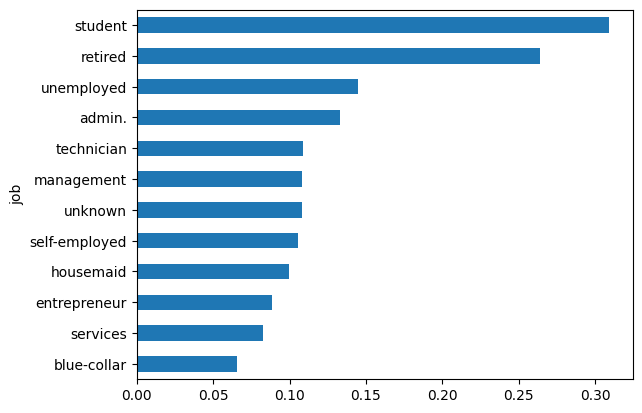

In [209]:
train.groupby('job')['y'].mean().sort_values().plot.barh()

In [211]:
def club_jobs(jobid):
    if jobid in ['student','retired']:
        return 'a_high'
    elif jobid in ['entrepreneur','services','blue-collar']:
        return 'c_low'
    else:
        return 'b_med'

In [215]:
train['job_clubbed_target']=train.job.apply(club_jobs)

job
technician       0.164482
services         0.095335
management       0.070474
retired          0.041630
entrepreneur     0.035512
self-employed    0.034865
housemaid        0.025703
unemployed       0.024635
student          0.021463
unknown          0.007802
Name: proportion, dtype: float64